In [1]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import h5py
import cupy


SMALLSIZE = 12
NORMALSIZE = 12
LARGESIZE = 12

params = {
    "font.family":"serif",
    "mathtext.fontset":"stix",
    "font.size": SMALLSIZE,
    "axes.titlesize" : SMALLSIZE,
    "axes.labelsize" : NORMALSIZE,
    'xtick.labelsize': SMALLSIZE,
    'ytick.labelsize': SMALLSIZE,      
    'legend.fontsize': SMALLSIZE,  
    'figure.titlesize': LARGESIZE,
    'pgf.texsystem' : "pdflatex"
}
matplotlib.rcParams.update(params)

# isob_dir = "../data/IsoB_dt10_all"
# snap_names = [f"GLX.000{10*(j):03.0f}" for j in range(1, 62)] + [f"GLX.0{10*j:04.0f}" for j in range(62, 101)]
# iord_dir  = "../data/fil_iords.csv"

# HDF5DIR = "../data/IsoB_faceon.h5"
# h5keys = [f"GLX{10*(x+1):04.0f}" for x in range(100)]

star_file = "../data/isob10_stars.h5"
fft_dir = "../data/fft_results"
stft_dir = "../data/fft_results/isob10_stft_psd2.h5"
rfft_dir = "../data/fft_results/isob10_rfft_psd.h5"

This generates the weighted power mean for each spatial dimension for all the stars along with the width measurement

In [2]:
output_file = f"{fft_dir}/isob10_stft_wfreq2.h5"

with h5py.File(stft_dir, "r") as stft_data, h5py.File(output_file, "w") as f_out:
    psd_ds = stft_data['psd']
    freqs = stft_data["freqs"][:]

    print(psd_ds.shape)
    
    n_stars = psd_ds.shape[0]
    n_win = psd_ds.shape[1]
    n_freqs = psd_ds.shape[2]
    n_spatial = psd_ds.shape[3]

    freqs_nodc = cupy.asarray(freqs[1:], dtype=cupy.float32)

    wmean_ds = f_out.create_dataset(
        "wmean",
        shape=(n_stars, n_win, n_spatial),
        dtype=np.float32,
        fillvalue=np.nan
    )
    width_ds = f_out.create_dataset(
        "width",
        shape=(n_stars, n_win, n_spatial),
        dtype=np.float32,
        fillvalue=np.nan
    )

    n_chunk_stars = 200000
    n_chunks = (n_stars + n_chunk_stars - 1) // n_chunk_stars

    for i, start in enumerate(range(0, n_stars, n_chunk_stars)):
        end = min(start + n_chunk_stars, n_stars)

        psd = cupy.asarray(psd_ds[start:end], dtype=cupy.float32)[:, :, 1:, :]
        
        total = cupy.nansum(psd, axis=2)

        wmean = cupy.nansum(psd*freqs_nodc[None, None, :, None], axis=2) / total
        width = cupy.sqrt(cupy.nansum(psd*(freqs_nodc[None, None, :, None] - wmean[:, :, None, :])**2, axis=2) / total)

        wmean_ds[start:end] = cupy.asnumpy(wmean)
        width_ds[start:end] = cupy.asnumpy(width)
        print(i, n_chunks)

(4590904, 9, 11, 3)
0 23
1 23
2 23
3 23
4 23
5 23
6 23
7 23
8 23
9 23
10 23
11 23
12 23
13 23
14 23
15 23
16 23
17 23
18 23
19 23
20 23
21 23
22 23


In [3]:
# r1, r2 = (2500000, 3000000)
r1, r2 = (0, 100000)

stft_wmean_dir = f"{fft_dir}/isob10_stft_wfreq2.h5"
with h5py.File(stft_wmean_dir, "r") as f:
    print(f['wmean'])
    test_mean = f['wmean'][r1:r2, :, :]

with h5py.File(stft_wmean_dir, "r") as f:
    print(f['width'])
    test_width = f['width'][r1:r2, :, :]

with h5py.File(stft_dir, "r") as f:
    stft_test = f['psd'][r1:r2, :, :]
    freqs = f['freqs'][:]
    t = f['frame_times_Myr'][:]
    print(t)

<HDF5 dataset "wmean": shape (4590904, 9, 3), type "<f4">
<HDF5 dataset "width": shape (4590904, 9, 3), type "<f4">
[100. 200. 300. 400. 500. 600. 700. 800. 900.]


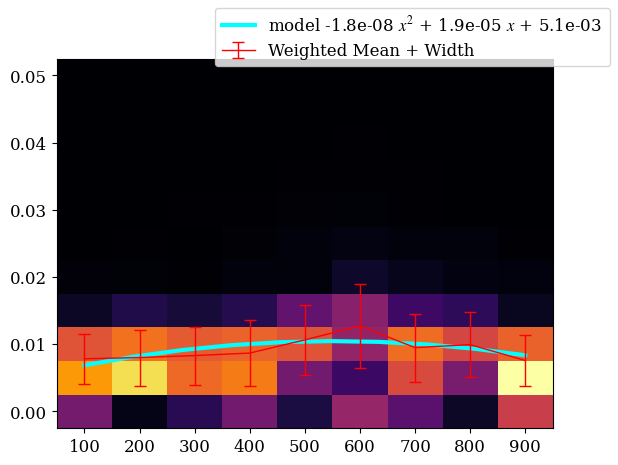

In [4]:
fig, ax = plt.subplots()

id = 170
sp = 0

mask = ~np.isnan(test_mean[id, :, sp])

ax.pcolormesh(t[mask], freqs, stft_test[id, :, :, sp][mask].T, cmap='inferno')
#ax.plot(t, test_mean[id, :, 0], c="red")


coeffs = np.polyfit(t[mask], test_mean[id, :, sp][mask], deg=2)
x = np.linspace(t[mask].min(), t[mask].max(), 10)
y = coeffs[0]*x**2 + coeffs[1]*x + coeffs[2]

ax.plot(x,y, label=f"model {coeffs[0]:.01e} $x^2$ + {coeffs[1]:.01e} $x$ + {coeffs[2]:.01e} ", c="cyan", linewidth=3)

ax.errorbar(t[mask], test_mean[id, :, sp][mask], yerr=test_width[id, :, sp][mask], capsize=4 , c="red", alpha=1, label="Weighted Mean + Width", linewidth=1)

fig.legend()




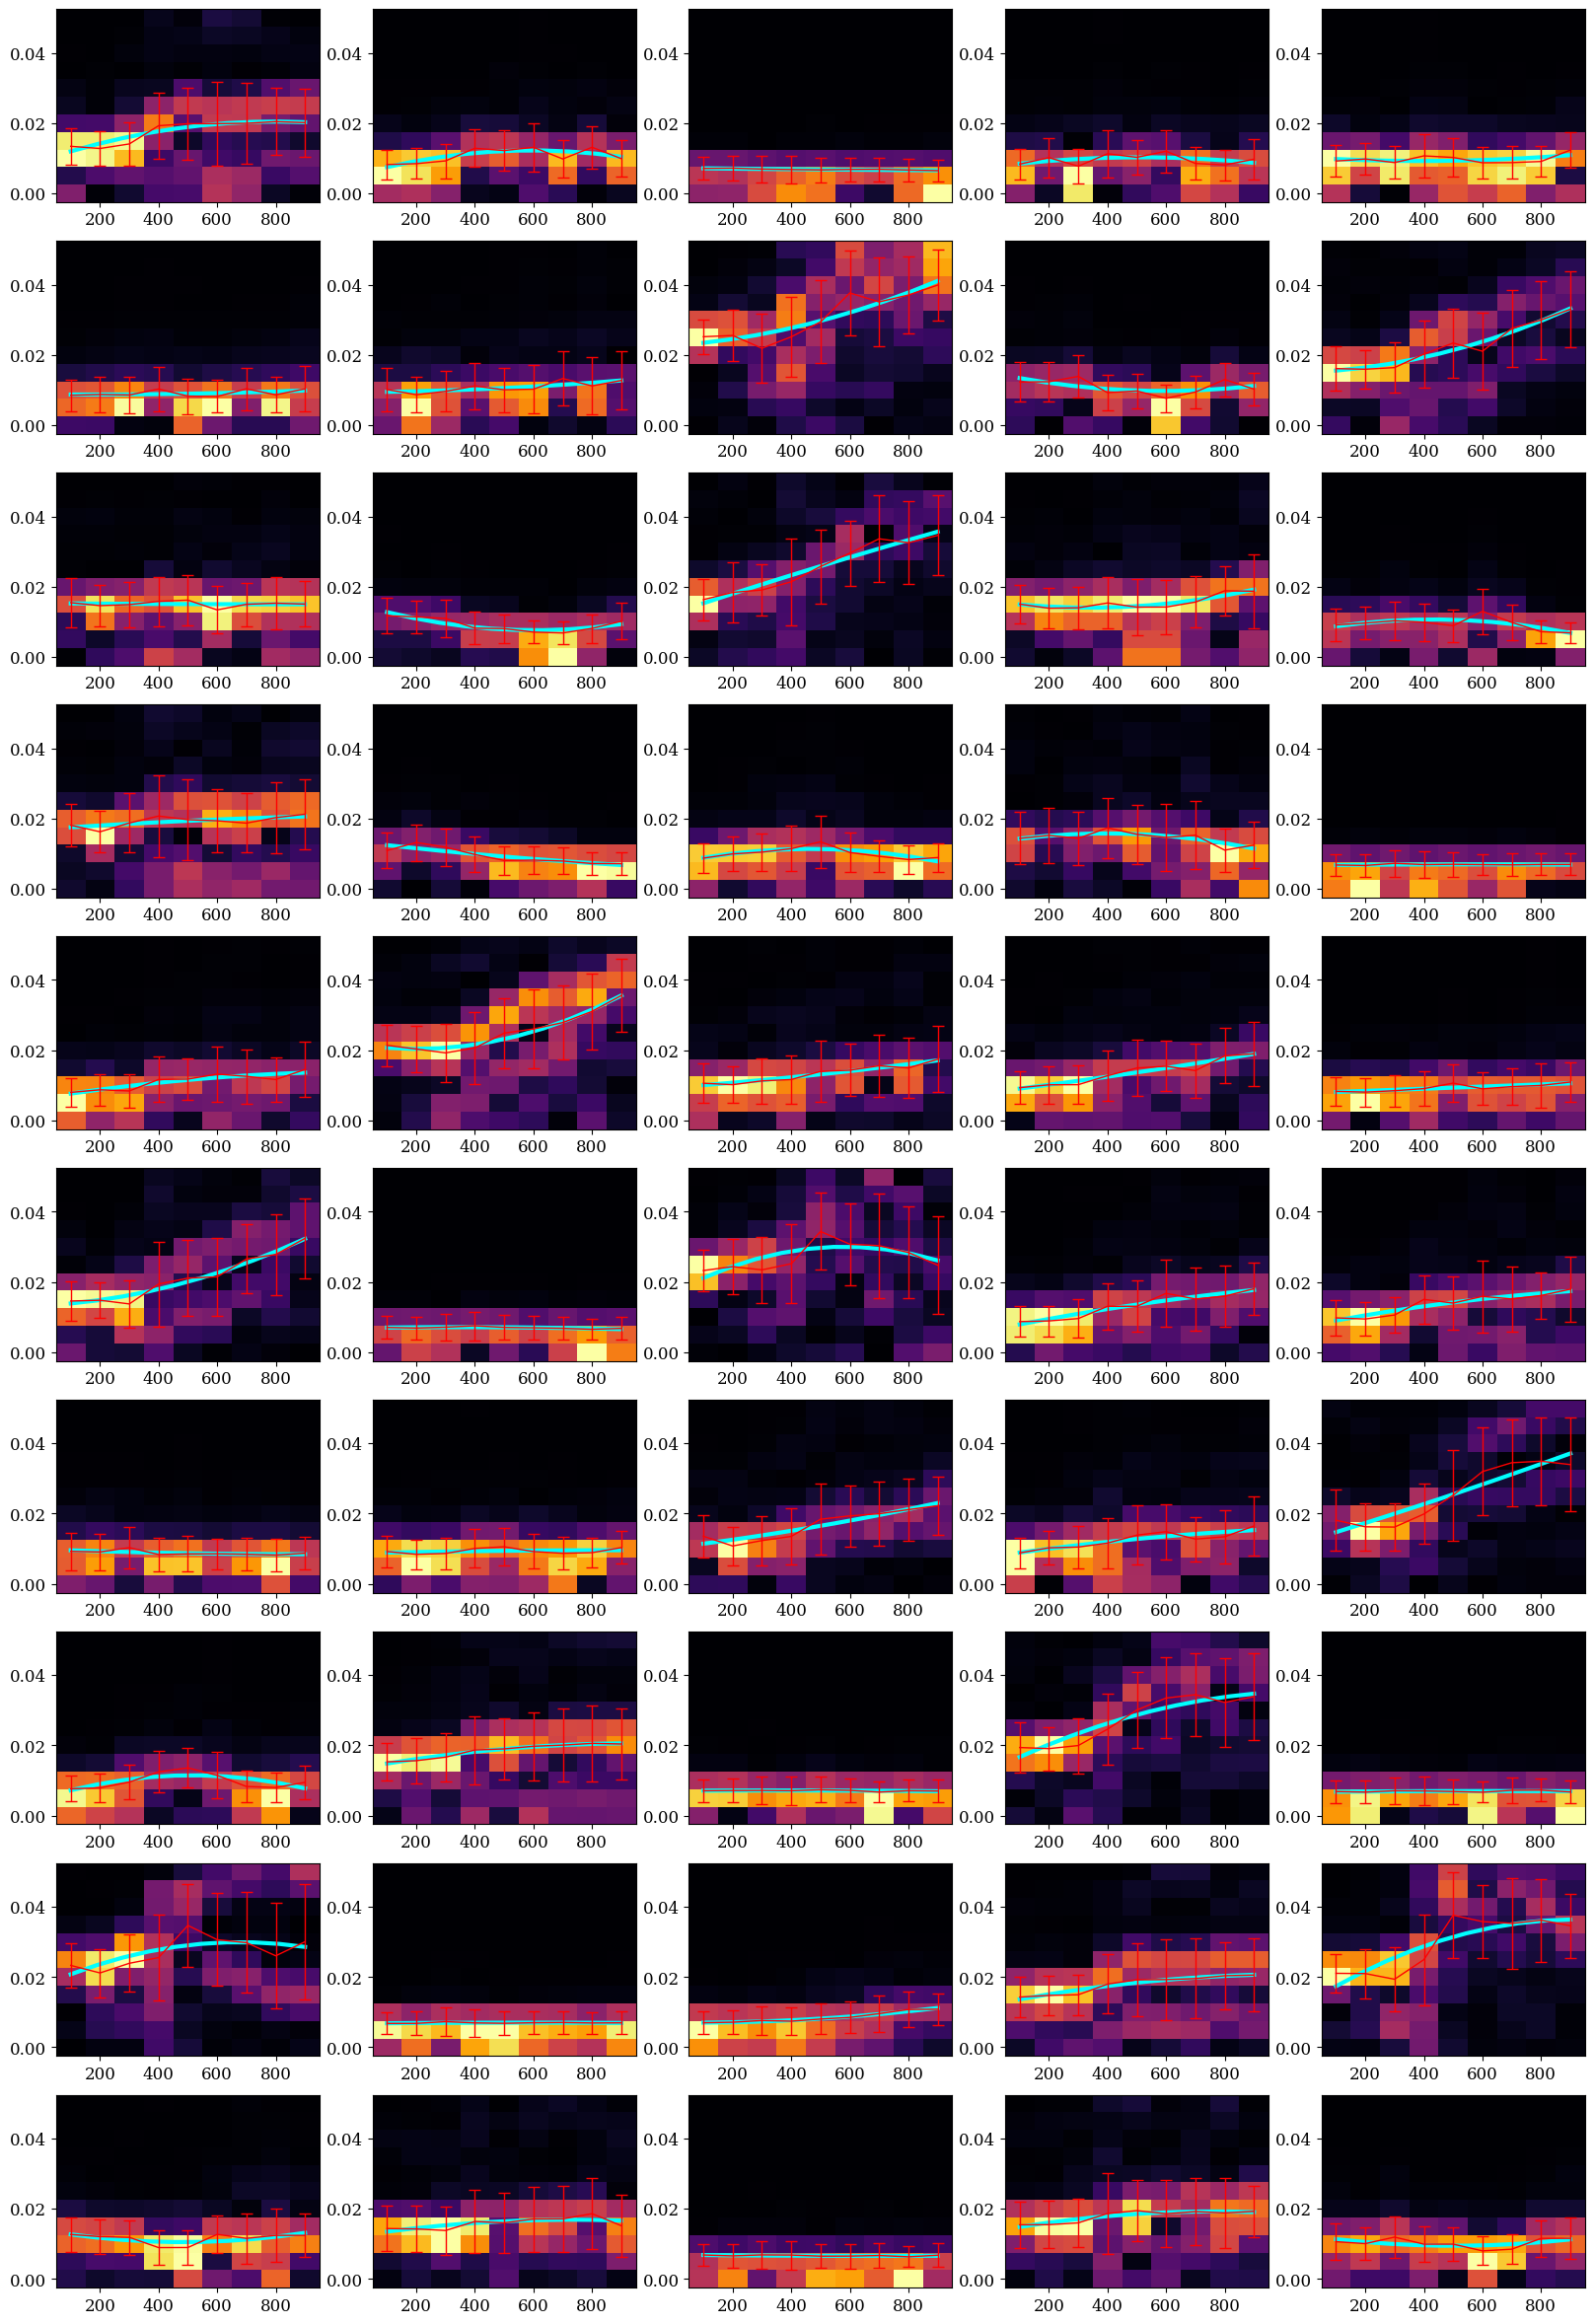

In [5]:
nrows, ncols = (10, 5)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
fig.set_size_inches(4*ncols, 3*nrows)
axes = axes.ravel()

ids = np.random.randint(r1-r1, r2-r1, nrows*ncols)

#print(ids)


for i, id in enumerate(ids):
    ax = axes[i]
    sp = 0 # spatial dimension

    mask = ~np.isnan(test_mean[id, :, sp])

    ax.pcolormesh(t[mask], freqs, stft_test[id, :, :, sp][mask].T, cmap='inferno')
    

    coeffs = np.polyfit(t[mask], test_mean[id, :, 0][mask], deg=2)
    x = np.linspace(t[mask].min(), t[mask].max(), 10)
    y = coeffs[0]*x**2 + coeffs[1]*x**1 + coeffs[2]
    #y = coeffs[0]*x**3 + coeffs[1]*x**2 + coeffs[2]*x + coeffs[3]

    ax.plot(x,y, label=f"model {coeffs[0]:.01e} $x^2$ + {coeffs[1]:.01e} $x$ + {coeffs[2]:.01e} ", c="cyan", linewidth=3)

    ax.errorbar(t, test_mean[id, :, sp], yerr=test_width[id, :, sp], capsize=4 , c="red", alpha=1, label="Weighted Mean + Width", linewidth=1)

    


In [7]:
with h5py.File(star_file, "r") as f:
    spatial_data = f['trajectories'][0:1000, :, :]

In [103]:
id = 6
sp = 1 
precision = 12

(1000, 9, 11, 3)
(100, 3)


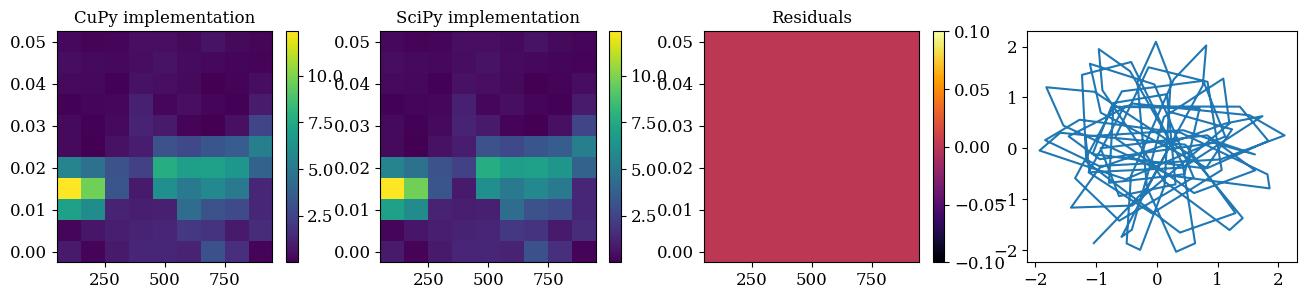

In [116]:
from cupyx.scipy.signal import stft as cupystft
from scipy.signal import stft as scipystft

cpu_data = spatial_data[id, :, :]


sf, st, sxx = scipystft(
    cpu_data.T,
    fs = 1/10,
    window = 'hann',
    nperseg=20,
    noverlap=20-10,
    nfft=20,
    boundary=None,
    padded=False,
    axis=-1,
    scaling='psd'
)

spsd = np.round(np.abs(sxx).transpose(2,1,0),precision)


gpu_data = cupy.asarray(spatial_data)
x = gpu_data.transpose(0, 2, 1)

f, t, zxx = cupystft(
    x,
    fs = 1/10,
    window='hann',
    nperseg=20,
    noverlap=20-10,
    nfft=20,
    boundary=None,
    padded=False,
    axis=-1,
    scaling='psd'
)

f = cupy.asnumpy(f)
t = cupy.asnumpy(t)
zxx = cupy.asnumpy(cupy.abs(zxx))

result = np.round(zxx.transpose(0, 3, 2, 1),precision)
print(result.shape)

fig, axes = plt.subplots(ncols = 4)
fig.set_size_inches(4*4, 3)
axes = axes.ravel()
ax = axes[0]
im = ax.pcolormesh(t, f, result[id, :, :, sp].T)
fig.colorbar(im, ax=ax)
ax.set_title("CuPy implementation")
ax = axes[1]
im = ax.pcolormesh(t, f, spsd[:, :, sp].T)
fig.colorbar(im, ax=ax)
ax.set_title("SciPy implementation")

ax = axes[2]
im = ax.pcolormesh(t, f, np.abs(result[id, :, :, sp].T - spsd[:, :, sp].T), cmap='inferno', vmin=0)
fig.colorbar(im, ax=ax)
ax.set_title("Residuals")


ax= axes[3]
print(cpu_data.shape)
ax.plot(cpu_data[:, 0], cpu_data[:, 1])

In [145]:
with h5py.File("../data/fft_results/isob10_stft_psd2.h5", "r") as f:
    print(f['psd'])
    aaa = f["psd"][0:10000, :, :, :]
    print(f.keys())
    t = f['frame_times_Myr'][:]
    freqs = f['freqs'][:]

with h5py.File("../data/isob10_stars.h5", "r") as f:
    spatial = f['trajectories'][0:10000, :, 0]


<HDF5 dataset "psd": shape (4590904, 9, 11, 3), type "<f4">
<KeysViewHDF5 ['frame_times_Myr', 'freqs', 'iord_map', 'psd', 'tform_steps']>


(10000, 9, 11, 3)
[100. 200. 300. 400. 500. 600. 700. 800. 900.] [0.    0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05 ]
-2.534240476862598e-07
8.952604602643563e-06
4.623830127808981e-08
6.160363541056479e-07
-0.0010038037560783338
3.5787522777632613e-06
7.120072842790176e-07
-1.295290883989754e-06
-1.5405463117583798e-06
9.790882454568592e-07
-2.1855253849456524e-06
4.518032063489247e-07
9.299814679800122e-08
-4.4101476577573795e-07
2.3253633908617427e-07
7.983807477068318e-06
-1.3699270907151576e-06
1.92969105644418e-06
2.3796688739669003e-07
1.2130215819462081e-06
3.569573153207328e-07
-9.74699854805125e-07
-1.199729770633151e-07
2.4970248452878957e-07
2.7066469234296453e-07
1.3889371891159796e-07
-1.8616421118234847e-06
-5.930364095456386e-07
-8.532404878677791e-07
-2.0650476253436523e-06
3.36945056675364e-07
2.4501234470800104e-07
6.970809854579471e-07
-1.156576164428394e-05
-3.5504102720166145e-06
1.3647079459486178e-06
8.942615194870371e-07
-2.690691498329588e-06
9.

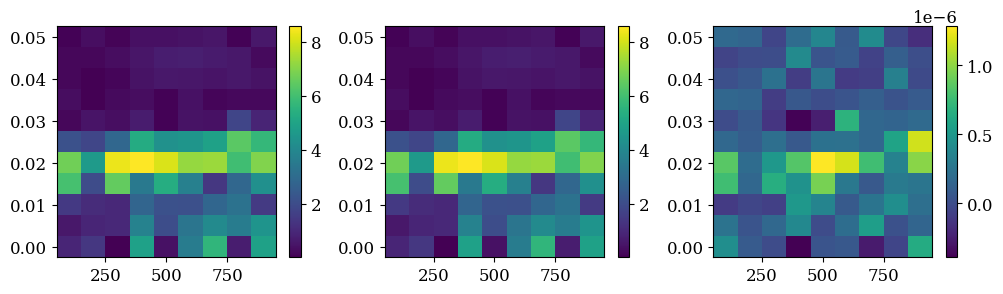

In [172]:
print(aaa.shape)
print(t, freqs)
from scipy.signal import stft as scipystft

precision = 3


residuals = []

for i in range(100):
    cpu_data = spatial[i, :]


    a, b, sxx = scipystft(
        cpu_data.T,
        fs = 1/10,
        window = 'hann',
        nperseg=20,
        noverlap=10,
        nfft=20,
        boundary=None,
        padded=False,
        axis=-1,
        scaling='psd'
    )

    #print(sxx.shape)

    # spsd = np.round(np.abs(sxx),precision)
    spsd = np.abs(sxx)

    residual = np.round(aaa[i, :, :, 0].T, precision) - np.round(spsd, precision)
    print(np.nansum(residual))

    residuals.append(np.nansum(residual))

    

test = np.asarray(residuals)
print("max is", test.max())



fig, axes = plt.subplots(ncols=3)
fig.set_size_inches(4*3, 3)
axes = axes.ravel()
#ax.pcolormesh(t, freqs, aaa[9, :, :, 0].T)
#ax.pcolormesh(t, freqs, spsd)
ax = axes[0]
im = ax.pcolormesh(t, freqs, aaa[99, :, :, 0].T)
fig.colorbar(im, ax=ax)

ax = axes[1]
im = ax.pcolormesh(t, freqs, spsd)
fig.colorbar(im, ax=ax)

ax = axes[2]
im = ax.pcolormesh(t, freqs, aaa[99, :, :, 0].T - spsd)
fig.colorbar(im, ax=ax)

# Linear Regression
This section is fitting a linear relationship to the weighted points and assessing the deviation

In [19]:
n_chunk_stars = 100000

with h5py.File(f"{fft_dir}/isob10_stft_wfreq2.h5", "r") as f_in, h5py.File(f"{fft_dir}/isob10_freq_linear.h5", "w") as f_out :
    wmean = f_in['wmean']
    n_stars, n_frames, n_spatial = wmean.shape
    t = np.arange(9)*100 + 100
    
    coeff_ds = f_out.create_dataset(
        "coeffs",
        shape=(n_stars, 2, n_spatial),
        dtype=np.float32,
        fillvalue=np.nan
    )

    rmse_ds = f_out.create_dataset(
        "rmse",
        shape=(n_stars, n_spatial),
        dtype=np.float32,
        fillvalue=np.nan
    )

    n_chunks = (n_stars + n_chunk_stars- 1) // n_chunk_stars

    for i, start in enumerate(range(0, n_stars, n_chunk_stars)):
        end = min(start + n_chunk_stars, n_stars)

        chunk = wmean[start:end]

        coeff_buf = np.full((end-start, 2, n_spatial), np.nan, dtype=np.float32)
        rmse_buf = np.full((end-start, n_spatial), np.nan, dtype=np.float32)

        for j in range(end-start):
            for sp in range(n_spatial):
                y = chunk[j, :, sp]
                mask = ~np.isnan(y)

                if mask.sum() < 3:
                    continue

                t_valid = t[mask]
                y_valid = y[mask]

                coeffs = np.polyfit(t_valid, y_valid, deg=1)
                y_pred = np.polyval(coeffs, t_valid)

                ss_res = np.sum((y_valid - y_pred) ** 2)

                coeff_buf[j, :, sp] = coeffs
                rmse_buf[j, sp] = np.sqrt(ss_res / mask.sum())
        
        coeff_ds[start:end] = coeff_buf
        rmse_ds[start:end] = rmse_buf
        print(f"{i} / {n_chunks}")



0 / 46
1 / 46
2 / 46
3 / 46
4 / 46
5 / 46
6 / 46
7 / 46
8 / 46
9 / 46
10 / 46
11 / 46
12 / 46
13 / 46
14 / 46
15 / 46
16 / 46
17 / 46
18 / 46
19 / 46
20 / 46
21 / 46
22 / 46
23 / 46
24 / 46
25 / 46
26 / 46
27 / 46
28 / 46
29 / 46
30 / 46
31 / 46
32 / 46
33 / 46
34 / 46
35 / 46
36 / 46
37 / 46
38 / 46
39 / 46
40 / 46
41 / 46
42 / 46
43 / 46
44 / 46
45 / 46


(1000, 100, 3)


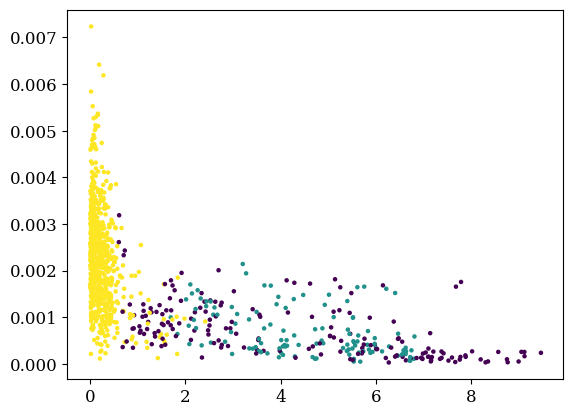

In [52]:
r1, r2 = (3000000, 3001000)

with h5py.File("../data/fft_results/isob10_freq_linear.h5") as f:
    rmse_x = f['rmse'][r1:r2, 0]

with h5py.File("../data/isob10_stars.h5") as f:
    xyz = f['trajectories'][r1:r2, :, :]

    labels = np.zeros(f['trajectories'].shape[0], dtype=np.int8)

all_iords = np.loadtxt("../data/all_iords.csv")
arm_iords = np.loadtxt("../data/arm_iords.csv")
bar_iords = pd.read_csv(("../data/barbyiord.csv")).to_numpy()



labels[np.isin(all_iords, arm_iords)] = 1
labels[np.isin(all_iords, bar_iords)] = 2

print(xyz.shape)

final_r = np.sqrt(xyz[:, -1, 0]**2 + xyz[:, -1, 1]**2)

fig, ax = plt.subplots()




ax.scatter(final_r, rmse_x, s=5, c = labels[r1:r2])

# Deprecated

In [21]:
with h5py.File(star_file, 'r') as f:
    data = f['trajectories']

    chunk = data[0:100, :, :]
    gpu_chunk = cupy.asarray(chunk, dtype=cupy.float32)

    fft = cupy.fft.rfft(gpu_chunk, axis=1)
    psd = cupy.abs(fft)**2

    print(fft.shape)

    del fft
    cupy.get_default_memory_pool().free_all_blocks()

(100, 51, 3)


(100, 51, 3)
[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05 ]


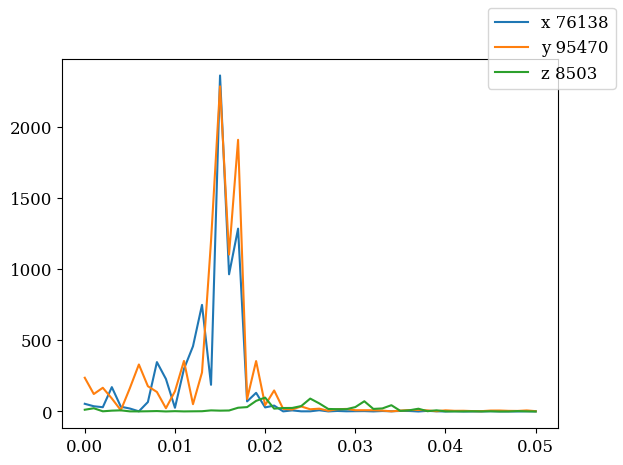

<Figure size 640x480 with 0 Axes>

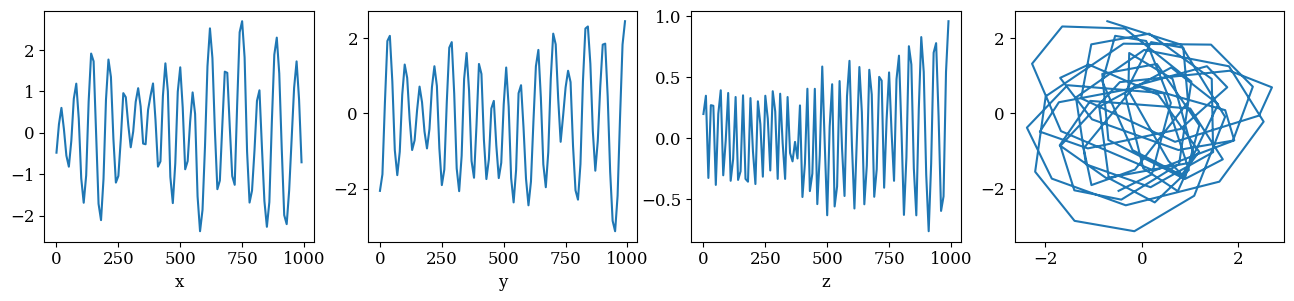

<Figure size 640x480 with 0 Axes>

In [145]:
psd = cupy.asnumpy(psd)
print(psd.shape)

id = 50


freqs = cupy.asnumpy(cupy.fft.rfftfreq(100, d=10))

print(freqs)

fig, ax = plt.subplots()
ax.plot(freqs, psd[id, :, 0], label=f"x {np.trapezoid(psd[id, :, 0], dx=10, axis=0):.0f}")
ax.plot(freqs, psd[id, :, 1], label=f"y {np.trapezoid(psd[id, :, 1], dx=10, axis=0):.0f}")
ax.plot(freqs, psd[id, :, 2], label=f"z {np.trapezoid(psd[id, :, 2], dx=10, axis=0):.0f}")
fig.legend()
plt.show()
plt.clf()
fig, axes = plt.subplots(ncols = 4)
fig.set_size_inches(4*4, 3)
axes = axes.ravel()
axes[0].plot(np.arange(100)*10, chunk[id, :, 0])
axes[0].set_xlabel("x")
axes[1].plot(np.arange(100)*10, chunk[id, :, 1])
axes[1].set_xlabel("y")
axes[2].plot(np.arange(100)*10, chunk[id, :, 2])
axes[2].set_xlabel("z")
axes[3].plot(chunk[id, :, 0], chunk[id, :, 1])

plt.show()
plt.clf()

C:\Users\Misha\AppData\Local\Temp\ipykernel_51116\3962195167.py:10: RankWarning: Polyfit may be poorly conditioned
  phi_tr = np.polyfit(tarr, phi, 100)


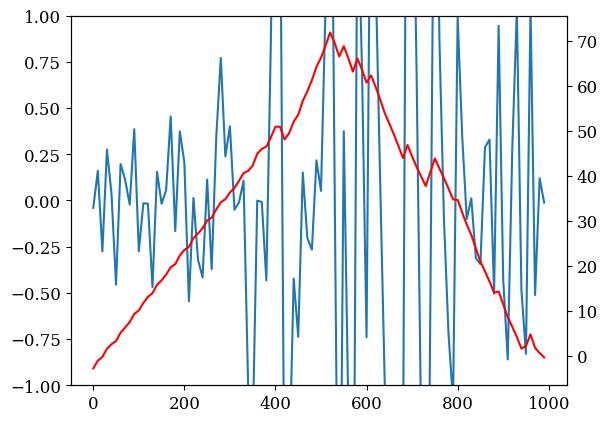

In [101]:
id=98

x = chunk[id, :, 0]
y = chunk[id, :, 1]
tarr = np.arange(100)*10

r = np.sqrt(x**2 + y**2)
phi = np.unwrap(np.atan2(y, x))

phi_tr = np.polyfit(tarr, phi, 100)
phi_res = phi - np.polyval(phi_tr, tarr)

fig, ax = plt.subplots()
ax.plot(tarr, phi_res)
ax.set_ylim(-1, 1)

ax1 = ax.twinx()
ax1.plot(tarr, phi, c="red")
